# Sketch → 3-D Pose  (CNN + GAT)

**Architecture**: sketch image → CNN backbone → per-joint node features → Graph Attention Network → MLP head → `(x, y, z, visibility)` per joint.

Visibility is predicted per joint and used as a loss mask so occluded joints still participate in graph message-passing but don't penalise training.

In [1]:
import os, re, random, pickle as pkl
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import tqdm
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# MediaPipe (only needed for data creation)
try:
    import mediapipe as mp
    from mediapipe.tasks import python
    from mediapipe.tasks.python import vision
    HAS_MEDIAPIPE = True
except ImportError:
    HAS_MEDIAPIPE = False
    print("MediaPipe not found – data-creation cells will be skipped.")

# torch-geometric (GAT)
try:
    from torch_geometric.nn import GATv2Conv
    HAS_PYG = True
except ImportError:
    HAS_PYG = False
    print("torch-geometric not found. Install with:\n"
          "  pip install torch-geometric")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE} | PyG: {HAS_PYG} | MediaPipe: {HAS_MEDIAPIPE}")


c:\Users\leahz\miniconda3\envs\AIR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu | PyG: True | MediaPipe: True


## Constants & Graph Definition

In [2]:
PATH = "C:/Users/leahz/Documents/ATC/pose-project/data"
IMG_SIZE = 128

NUM_JOINTS = 33
COORD_DIM  = 3   # x, y, z

# ── Skeleton edges (from your spec) ──────────────────────────────────────────
EDGES_RAW = [
    # head
    (8,6),(6,5),(5,4),(4,0),(0,1),(1,2),(2,3),(3,7),(10,9),
    # neck
    (10,12),(9,11),(8,12),(7,11),
    # torso
    (12,11),(12,24),(24,23),(23,11),(12,23),(11,24),
    # left arm
    (11,13),(13,15),(11,15),(15,21),(15,19),(19,17),(15,17),
    # right arm
    (12,14),(14,16),(12,16),(16,22),(16,20),(20,18),(16,18),
    # left leg
    (24,26),(26,28),(24,28),(23,26),
    # right leg
    (23,25),(25,27),(23,27),(24,25),
    # left foot
    (28,30),(30,32),(32,28),
    # right foot
    (27,29),(29,31),(31,27),
]

# Undirected: add reverse edges → COO format for PyG
def build_edge_index(edges_raw, num_joints=NUM_JOINTS):
    src, dst = [], []
    seen = set()
    for a, b in edges_raw:
        for u, v in [(a, b), (b, a)]:
            if (u, v) not in seen:
                src.append(u); dst.append(v)
                seen.add((u, v))
    ei = torch.tensor([src, dst], dtype=torch.long)
    return ei

EDGE_INDEX = build_edge_index(EDGES_RAW)  # (2, num_directed_edges)
print(f"Graph: {NUM_JOINTS} nodes, {EDGE_INDEX.shape[1]} directed edges "
      f"({len(EDGES_RAW)} undirected)")

# Joint categories (for weighted loss & visualisation)
JOINT_CATEGORIES = {
    "head":       [0,1,2,3,4,5,6,7,8,9,10],
    "torso":      [11,12,23,24],
    "left_arm":   [11,13,15,17,19,21],
    "right_arm":  [12,14,16,18,20,22],
    "left_leg":   [23,25,27],
    "right_leg":  [24,26,28],
    "left_hand":  [15,17,18,19,20,22],
    "right_hand": [16,18,19,20,21],
    "left_foot":  [28,30,32],
    "right_foot": [27,29,31],
}

JOINT_TO_CAT = {}
for cat, idxs in JOINT_CATEGORIES.items():
    for i in idxs:
        JOINT_TO_CAT[i] = cat

# Per-joint loss weight tensor
JOINT_WEIGHTS = torch.ones(NUM_JOINTS)
for j in [11,12,23,24]:   # torso anchors – high weight
    JOINT_WEIGHTS[j] = 3.0
for j in [13,14,25,26]:   # elbows / knees
    JOINT_WEIGHTS[j] = 2.0


Graph: 33 nodes, 94 directed edges (47 undirected)


## Skeleton Renderer 

In [3]:
class Skeleton:
    def __init__(self, joints, edges, joint_meta=None, edge_meta=None):
        self.joints    = joints.astype(float)
        self.edges     = edges.astype(int)
        self.joint_meta = joint_meta if joint_meta else [{} for _ in range(len(joints))]
        self.edge_meta  = edge_meta  if edge_meta  else [{} for _ in range(len(edges))]

    def jitter_joints(self, sigma=0.01):
        self.joints += np.random.normal(0, sigma, self.joints.shape)

    def _scale_line(self, p1, p2, scale):
        p1, p2 = np.array(p1), np.array(p2)
        mid = (p1 + p2) / 2.0
        vec = p2 - p1
        return tuple((mid - vec*scale/2).astype(int)), tuple((mid + vec*scale/2).astype(int))

    def _get_bezier_curve(self, p1, p2, bend_factor=0.3, num_points=15):
        p1, p2 = np.array(p1), np.array(p2)
        mid  = (p1 + p2) / 2.0
        perp = np.array([-(p2[1]-p1[1]), p2[0]-p1[0]])
        ctrl = mid + perp * bend_factor
        t = np.linspace(0, 1, num_points)[:, None]
        return ((1-t)**2*p1 + 2*(1-t)*t*ctrl + t**2*p2).astype(np.int32)

    def _get_line_segments(self, p1, p2, num_segments=10):
        x = np.linspace(p1[0], p2[0], num_segments)
        y = np.linspace(p1[1], p2[1], num_segments)
        return np.vstack([x, y]).T.astype(np.int32)

    def render(self, size=256, noise_level=3):
        canvas = np.zeros((size, size, 4), dtype=np.uint8)
        z_vals = self.joints[:, 2]
        z_min, z_max = z_vals.min(), z_vals.max()
        z_range = max(z_max - z_min, 1e-6)
        get_alpha = lambda z: int((1.0 - (z - z_min)/z_range)*205 + 50)

        # head ellipse
        p0 = self.joints[0,:2]*size
        p7, p8 = self.joints[7,:2]*size, self.joints[8,:2]*size
        p1_, p4_ = self.joints[1,:2]*size, self.joints[4,:2]*size
        r1  = int(np.linalg.norm(p8 - p7)/2)
        r2  = int(2*np.linalg.norm((p4_+p1_)/2 - p0))
        cv2.ellipse(canvas, tuple(p0.astype(int)), (r1, r2),
                    0, 0, 360, (0,0,0,get_alpha(self.joints[0,2])), 2)

        for i, (a, b) in enumerate(self.edges):
            meta = self.edge_meta[i]
            if not meta.get("visible", True) or meta.get("category") == "head":
                continue
            p1e = tuple((self.joints[a,:2]*size).astype(int))
            p2e = tuple((self.joints[b,:2]*size).astype(int))
            sc  = meta.get("length_scale", 1.0)
            if sc != 1.0:
                p1e, p2e = self._scale_line(p1e, p2e, sc)
            alpha = get_alpha((self.joints[a,2]+self.joints[b,2])/2)
            color = (0,0,0,alpha)
            base_t = meta.get("thickness", 2)
            for _ in range(meta.get("sketch_strokes", 1)):
                sp1 = (p1e[0]+np.random.randint(-noise_level,noise_level+1),
                       p1e[1]+np.random.randint(-noise_level,noise_level+1))
                sp2 = (p2e[0]+np.random.randint(-noise_level,noise_level+1),
                       p2e[1]+np.random.randint(-noise_level,noise_level+1))
                if meta.get("style") == "curve":
                    pts = self._get_bezier_curve(sp1, sp2,
                              meta.get("bend",0.3)+np.random.uniform(-0.05,0.05))
                else:
                    l = np.linalg.norm(np.array(sp1)-np.array(sp2))
                    pts = self._get_line_segments(sp1, sp2, max(4, int(l//15)))
                for k in range(len(pts)-1):
                    t_ = max(1, base_t+np.random.randint(-1,2))
                    cv2.line(canvas, tuple(pts[k]), tuple(pts[k+1]), color, t_)

        for i, joint in enumerate(self.joints):
            meta = self.joint_meta[i]
            if not meta.get("visible", True):
                continue
            c = tuple((joint[:2]*size).astype(int))
            a = get_alpha(joint[2])
            cv2.circle(canvas, c, 2, (0,0,0,a), -1)
            if meta.get("draw_outer_ring"):
                rr = meta.get("ring_radius", 6)
                cv2.circle(canvas, (c[0]+np.random.randint(-2,3),
                                    c[1]+np.random.randint(-2,3)),
                           rr, (0,0,0,a), max(1,np.random.randint(1,3)))
        return canvas


def composite_sketch_on_white(rgba):
    bg    = np.ones_like(rgba[:,:,:3]) * 255
    alpha = rgba[:,:,3:] / 255.0
    return (rgba[:,:,:3]*alpha + bg*(1-alpha)).astype(np.uint8)


## MediaPipe Skeleton Builder

In [4]:
def construct_skeleton_from_mediapipe_result(detection_result, edges,
                                              normalize_to_bbox=True,
                                              bbox_padding=0.2):
    if not detection_result.pose_landmarks:
        raise ValueError("No pose landmarks in detection_result.")
    landmarks  = detection_result.pose_landmarks[0]
    joints, joint_meta = [], []
    for i, lm in enumerate(landmarks):
        cat = JOINT_TO_CAT.get(i)
        joints.append([lm.x, lm.y, lm.z])
        joint_meta.append({"category": cat, "visibility": lm.visibility})
    joints = np.array(joints, dtype=float)

    if normalize_to_bbox:
        vis_mask = np.array([m["visibility"] >= 0.5 for m in joint_meta])
        visible_xy = joints[vis_mask, :2] if vis_mask.any() else joints[:, :2]
        mn, mx = visible_xy.min(0), visible_xy.max(0)
        center = (mn + mx) / 2.0
        size_  = (mx - mn).max() * (1.0 + 2.0*bbox_padding)
        joints[:, :2] = (joints[:, :2] - center) / max(size_, 1e-6) + 0.5

    edge_meta = []
    for a, b in edges:
        vis = joint_meta[a]["visibility"] >= 0.5 and joint_meta[b]["visibility"] >= 0.5
        edge_meta.append({"visible": vis, "thickness": 2})

    return Skeleton(joints=joints, edges=np.array(edges, dtype=int),
                    joint_meta=joint_meta, edge_meta=edge_meta)


def stylize_as_sketch(skeleton):
    # 1. Add circles to specific joints
    target_joints = [11, 12, 13, 14, 25, 26]
    for idx in target_joints:
        skeleton.joint_meta[idx]["draw_outer_ring"] = True
        skeleton.joint_meta[idx]["ring_radius"] = np.random.randint(2, 8) # Varying sizes

    # 2. Torso Logic: Bulge thinner rectangles
    # Measure shoulder width (11 to 12) vs torso height (11 to 23)
    p11, p12, p23 = skeleton.joints[11], skeleton.joints[12], skeleton.joints[23]
    width = np.linalg.norm(p12 - p11)
    height = np.linalg.norm(p23 - p11)
    
    # Find the edges corresponding to the torso sides and curve them if thin
    if width / (height + 1e-5) < 0.6: # If thin
        for i, (a, b) in enumerate(skeleton.edges):
            if (a, b) in [(12, 24), (11, 23), (24, 12), (23, 11)]: # Left and right sides
                skeleton.edge_meta[i]["style"] = "curve"
                # Bend left side left, right side right
                skeleton.edge_meta[i]["bend"] = 0.3 if a in [12, 24] else -0.3 

    # 3. Arms/Legs: Sketchy, overlapping lines & Length variation
    sketch_categories = ["left_arm", "right_arm", "left_leg", "right_leg"]
    for i, (a, b) in enumerate(skeleton.edges):
        cat_a = skeleton.joint_meta[a].get("category")
        cat_b = skeleton.joint_meta[b].get("category")
        
        if cat_a in sketch_categories or cat_b in sketch_categories:
            # Tell the renderer to draw 3 jittery lines instead of 1
            skeleton.edge_meta[i]["sketch_strokes"] = 3
            
            # Randomly make the line 10% shorter (0.9) to 20% longer (1.2)
            skeleton.edge_meta[i]["length_scale"] = np.random.uniform(0.9, 1.2)
            
    return skeleton


## Dataset Creation

Each sample stores the **sketch image**, the **raw 3-D joint coordinates** (x, y, z in [0,1] / normalised), and the **per-joint visibility** float. No heatmaps needed – the graph directly predicts coordinates.

In [5]:
@dataclass
class PoseSample:
    """One training example stored to disk."""
    sketch:     np.ndarray   # uint8 RGB (64, 64, 3)
    coords:     np.ndarray   # float32 (33, 3) – normalised x,y,z
    visibility: np.ndarray   # float32 (33,)  – MediaPipe visibility


EDGES_TUPLE = [tuple(e) for e in EDGES_RAW]  # for Skeleton constructor
# joints is all the landmarks 
# edges are the tuples of indices into the joints array that define the skeleton structure that I choose
edges = [
    # head 
    (8,6),(6,5),(5,4),(4,0),(0,1),(1,2),(2,3),(3,7),(10,9),
    # torso
    (12,11), (24,23), (12,24), (11,23),
    # left-leg
    (24,26), (26,28),
    # right-leg
    (23,25), (25,27),
    # left-arm
    (12,14), (14,16),
    # right-arm
    (11,13), (13,15),
    # left foot
    (28,30), (30,32), (32,28),
    # right foot
    (27,29), (29,31), (31,27),
    # left hand
    (16,18), (18,20), (20,16), (16,22),
    # right hand
    (15,17), (17,19), (19,15), (15,21)
]

JOINT_CATEGORIES = {
    "head": [0,1,2,3,4,5,6,7,8,9,10],
    "torso": [11,12,23,24],
    "left_arm": [11,13,15],
    "right_arm": [12,14,16],
    "left_leg": [23,25,27],
    "right_leg": [24,26,28],
    "left_hand": [15,17,18,19,20,22],
    "right_hand": [16,18,19,20,21],
    "left_foot": [28,30,32],
    "right_foot": [27,29,31]
}




def extract_sample_from_detection(detection_result, edges=edges,
                                  bbox_padding=0.2) -> PoseSample:
    """Build one PoseSample from a MediaPipe detection result."""
    skeleton = construct_skeleton_from_mediapipe_result(
        detection_result, edges,
        normalize_to_bbox=True, bbox_padding=bbox_padding)

    coords     = skeleton.joints.astype(np.float32)        # (33, 3)
    visibility = np.array([m["visibility"] for m in skeleton.joint_meta],
                          dtype=np.float32)                # (33,)

    stylized = stylize_as_sketch(skeleton)
    rgba     = stylized.render(size=128)
    sketch   = composite_sketch_on_white(rgba)             # (128,128,3)
    sketch   = cv2.resize(sketch, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    return PoseSample(sketch=sketch, coords=coords, visibility=visibility)


def create_gat_dataset(image_series, output_folder, sample_limit=1,
                       image_base_path="", jitter_sigma=0.02,
                       vis_cutoff=0.3):
    """
    Iterate over image_series (pandas Series of filenames), run MediaPipe,
    and save PoseSample pickles.  Returns a list of saved paths.
    Logs details about skipped images for debugging.
    """
    if not HAS_MEDIAPIPE:
        raise RuntimeError("MediaPipe is required for dataset creation.")

    base_options = python.BaseOptions(
        model_asset_path=f"{PATH}/pose_landmarker_full.task")
    detector = vision.PoseLandmarker.create_from_options(
        vision.PoseLandmarkerOptions(base_options=base_options,
                                     output_segmentation_masks=False))

    out_dir = Path(output_folder)
    out_dir.mkdir(parents=True, exist_ok=True)
    base_path = Path(image_base_path) if image_base_path else None

    saved_paths = []
    skip_counts = {
        "invalid_filename": 0,
        "file_not_found": 0,
        "read_error": 0,
        "no_pose_detected": 0,
        "low_visibility": 0,
        "extraction_error": 0,
    }

    for idx, (key, row) in enumerate(tqdm.tqdm(image_series.items(),
                                                total=len(image_series))):
        img_filename = str(row).strip()
        if not img_filename or img_filename.lower() == "nan":
            skip_counts["invalid_filename"] += 1
            continue
        img_path = (base_path / img_filename) if base_path else Path(img_filename)
        if not img_path.exists():
            skip_counts["file_not_found"] += 1
            continue

        try:
            image = mp.Image.create_from_file(str(img_path))
            result = detector.detect(image)
        except Exception as e:
            skip_counts["read_error"] += 1
            print(f"  WARNING: failed to read/detect {img_path.name}: {e}")
            continue

        if not result.pose_landmarks:
            skip_counts["no_pose_detected"] += 1
            # print(f"  WARNING: no pose detected, skipping: {img_path.name}")
            continue

        # Low-visibility guard
        raw_vis = np.array([lm.visibility
                            for lm in result.pose_landmarks[0]], dtype=np.float32)
        if raw_vis.mean() < vis_cutoff:
            skip_counts["low_visibility"] += 1
            print(f"  WARNING: low visibility (mean={raw_vis.mean():.3f}), skipping: {img_path.name}")
            continue

        stem = Path(img_filename).stem

        # base sample (no jitter for first copy)
        try:
            base_sample = extract_sample_from_detection(result)
        except Exception as e:
            skip_counts["extraction_error"] += 1
            print(f"  WARNING: failed to extract sample {img_path.name}: {e}")
            continue

        for i in range(sample_limit):
            # For copies > 0, jitter the coords
            sample = PoseSample(
                sketch     = base_sample.sketch.copy(),
                coords     = base_sample.coords.copy(),
                visibility = base_sample.visibility.copy(),
            )
            if i > 0:
                sample.coords += np.random.normal(0, jitter_sigma,
                                                  sample.coords.shape).astype(np.float32)
                sample.coords  = np.clip(sample.coords, 0.0, 1.0)

            out_path = out_dir / f"{stem}_{i}.pkl"
            with open(out_path, "wb") as f:
                pkl.dump(sample, f)
            saved_paths.append(str(out_path))

        if (idx+1) % 500 == 0:
            print(f"  processed {idx+1} images → {len(saved_paths)} samples (skipped: {sum(skip_counts.values())})")

    # Save manifest
    manifest_path = out_dir / "manifest.txt"
    manifest_path.write_text("\n".join(saved_paths))
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"Dataset Creation Summary")
    print(f"{'='*60}")
    print(f"✓ Total samples saved: {len(saved_paths)}")
    print(f"\nSkip reasons:")
    for reason, count in skip_counts.items():
        if count > 0:
            print(f"  • {reason}: {count}")
    print(f"  TOTAL SKIPPED: {sum(skip_counts.values())}")
    print(f"\nOutput: {out_dir}")
    print(f"Manifest: {manifest_path}")
    print(f"{'='*60}\n")
    return saved_paths


### Run Data Creation  *(skip if already done)*

In [7]:
import pandas as pd
df = pd.read_csv(f"{PATH}/data.csv")
saved = create_gat_dataset(
    df["img_paths"],
    output_folder=f"{PATH}/GAT_data",
    image_base_path=f"{PATH}/mpii_human_pose_v1/images",
    sample_limit=5,
)
print("Data creation cell – uncomment to run.")


  4%|▍         | 501/11503 [00:44<15:47, 11.62it/s]

  processed 500 images → 2255 samples (skipped: 49)


  9%|▊         | 1001/11503 [01:26<14:55, 11.73it/s]

  processed 1000 images → 4545 samples (skipped: 91)


 13%|█▎        | 1502/11503 [02:08<13:59, 11.91it/s]

...

  processed 11000 images → 50400 samples (skipped: 920)


100%|█████████▉| 11501/11503 [16:29<00:00, 11.34it/s]

  processed 11500 images → 52715 samples (skipped: 957)


100%|██████████| 11503/11503 [16:29<00:00, 11.62it/s]



Dataset Creation Summary
✓ Total samples saved: 52730

Skip reasons:
  • no_pose_detected: 956
  • low_visibility: 1
  TOTAL SKIPPED: 957

Output: C:\Users\leahz\Documents\ATC\pose-project\data\GAT_data
Manifest: C:\Users\leahz\Documents\ATC\pose-project\data\GAT_data\manifest.txt

Data creation cell – uncomment to run.


### Inspect Sample Data


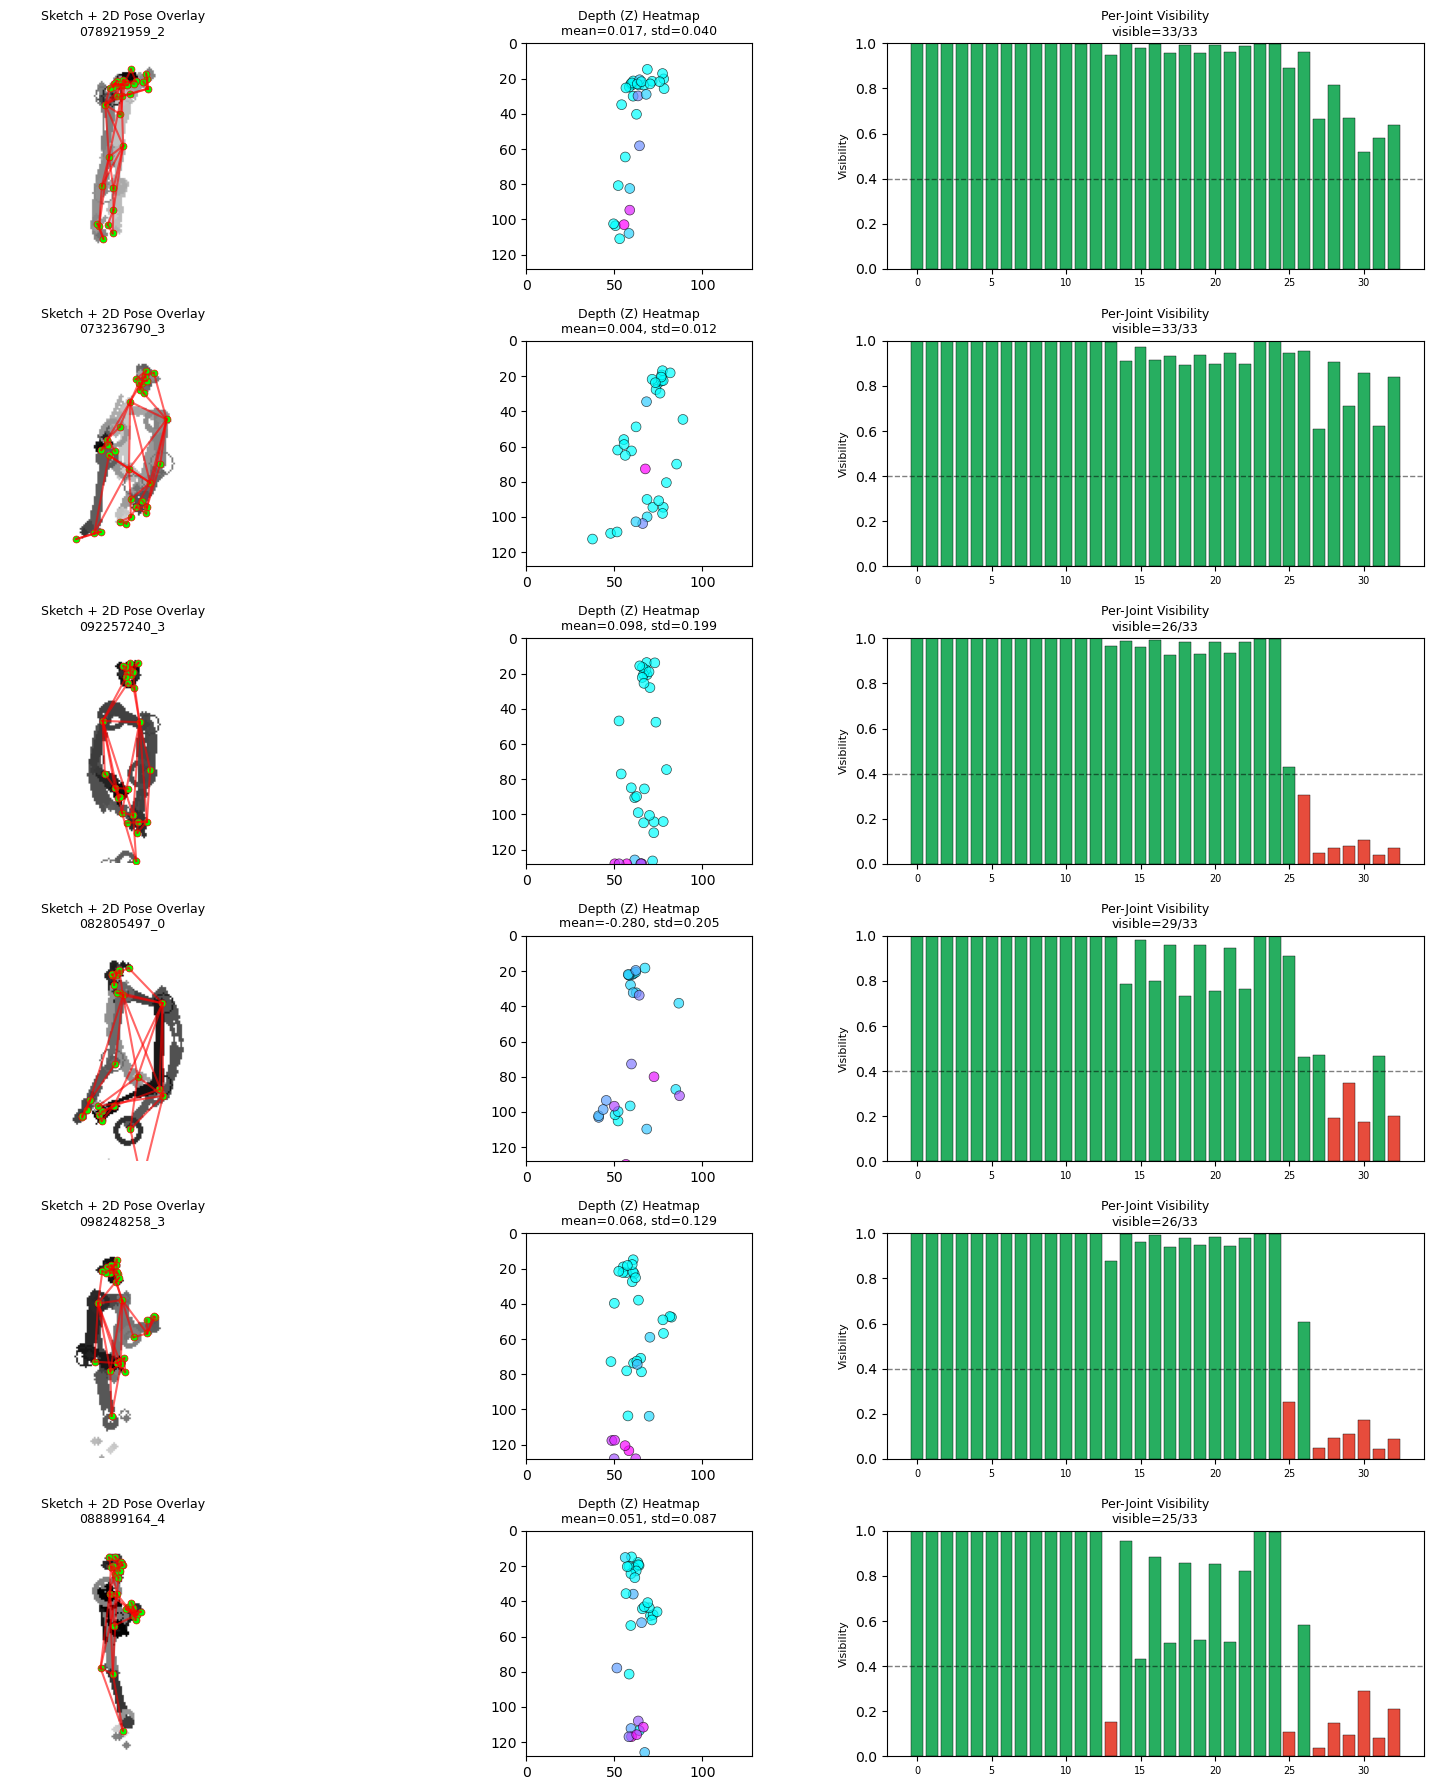


✓ Displayed 6 random samples from dataset
  Sketch size: 128×128 pixels
  Coordinates: normalized to [0, 1] range
  Green joints: visible (visibility ≥ 0.4)
  Red joints: occluded (visibility < 0.4)


In [8]:
def load_and_display_samples(manifest_path: str, num_samples: int = 6, 
                             vis_threshold: float = 0.4):
    """
    Load random samples from manifest and visualize:
    - Sketch image (cropped 64x64)
    - Overlay of 3D pose on the sketch
    - Per-joint visibility bar chart
    """
    paths = Path(manifest_path).read_text().strip().splitlines()
    if not paths:
        print("No samples found in manifest!")
        return
    
    # Sample random pickle files
    sample_paths = random.sample(paths, min(num_samples, len(paths)))
    
    fig = plt.figure(figsize=(16, 3*num_samples))
    
    for plot_idx, pkl_path in enumerate(sample_paths):
        with open(pkl_path, "rb") as f:
            sample: PoseSample = pkl.load(f)
        
        sketch_rgb = sample.sketch  # uint8 (64, 64, 3)
        coords = sample.coords      # float32 (33, 3) normalized [0,1]
        vis = sample.visibility     # float32 (33,)
        
        # Panel 1: Sketch with 2D pose overlay
        ax1 = plt.subplot(num_samples, 3, plot_idx*3 + 1)
        sketch_display = sketch_rgb.copy().astype(np.float32) / 255.0
        ax1.imshow(sketch_display)
        
        # Draw skeleton overlay in 2D (XY projection normalized to image space)
        vis_mask = vis >= vis_threshold
        for (a, b) in EDGES_RAW:
            if vis_mask[a] and vis_mask[b]:
                x1, y1 = coords[a, 0] * IMG_SIZE, coords[a, 1] * IMG_SIZE
                x2, y2 = coords[b, 0] * IMG_SIZE, coords[b, 1] * IMG_SIZE
                ax1.plot([x1, x2], [y1, y2], 'r-', linewidth=1.5, alpha=0.6)
        
        # Joint circles
        for j in range(len(coords)):
            if vis_mask[j]:
                x, y = coords[j, 0] * IMG_SIZE, coords[j, 1] * IMG_SIZE
                ax1.scatter(x, y, s=25, c='lime', edgecolor='red', linewidth=0.5)
        
        ax1.set_title(f"Sketch + 2D Pose Overlay\n{Path(pkl_path).stem}", fontsize=9)
        ax1.set_xlim(0, IMG_SIZE); ax1.set_ylim(IMG_SIZE, 0)
        ax1.axis('off')
        
        # Panel 2: Z (depth) visualization
        ax2 = plt.subplot(num_samples, 3, plot_idx*3 + 2)
        z_vals = coords[:, 2]
        z_norm = (z_vals - z_vals.min()) / (z_vals.max() - z_vals.min() + 1e-6)
        
        ax2.scatter(coords[:, 0] * IMG_SIZE, coords[:, 1] * IMG_SIZE, 
                   c=z_norm, s=50, cmap='cool', alpha=0.7, 
                   edgecolor='k', linewidth=0.5)
        ax2.set_title(f"Depth (Z) Heatmap\nmean={z_vals.mean():.3f}, std={z_vals.std():.3f}", fontsize=9)
        ax2.set_xlim(0, IMG_SIZE); ax2.set_ylim(IMG_SIZE, 0)
        ax2.set_aspect('equal')
        
        # Panel 3: Per-joint visibility
        ax3 = plt.subplot(num_samples, 3, plot_idx*3 + 3)
        colors = ['#27ae60' if v >= vis_threshold else '#e74c3c' for v in vis]
        ax3.bar(range(NUM_JOINTS), vis, color=colors, width=0.8, edgecolor='k', linewidth=0.3)
        ax3.axhline(vis_threshold, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax3.set_title(f"Per-Joint Visibility\nvisible={vis_mask.sum()}/{NUM_JOINTS}", fontsize=9)
        ax3.set_ylim(0, 1)
        ax3.set_xticks(range(0, NUM_JOINTS, 5))
        ax3.set_xticklabels(range(0, NUM_JOINTS, 5), fontsize=7)
        ax3.set_ylabel('Visibility', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Displayed {len(sample_paths)} random samples from dataset")
    print(f"  Sketch size: {IMG_SIZE}×{IMG_SIZE} pixels")
    print(f"  Coordinates: normalized to [0, 1] range")
    print(f"  Green joints: visible (visibility ≥ {vis_threshold})")
    print(f"  Red joints: occluded (visibility < {vis_threshold})")


# Load and visualize samples (update path if needed)
try:
    manifest_file = f"{PATH}/GAT_data/manifest.txt"
    if Path(manifest_file).exists():
        load_and_display_samples(manifest_file, num_samples=6, vis_threshold=0.4)
    else:
        print(f"Manifest not found at {manifest_file}")
        print("Run data creation first!")
except Exception as e:
    print(f"Error loading samples: {e}")
    import traceback
    traceback.print_exc()


## Chunked Dataset Cache

In [9]:
class GATSketchDataset(Dataset):
    """Loads PoseSample pickles from a manifest file."""

    def __init__(self, manifest_path: str, augment: bool = False):
        self.paths   = Path(manifest_path).read_text().strip().splitlines()
        self.augment = augment

    def __len__(self):  
        return len(self.paths)

    def __getitem__(self, idx):
        with open(self.paths[idx], "rb") as f:
            s: PoseSample = pkl.load(f)

        sketch = s.sketch.astype(np.float32) / 255.0  # (IMG_SIZE,IMG_SIZE,3)
        if self.augment and random.random() < 0.5:
            sketch = sketch[:, ::-1, :].copy()  # horizontal flip

        sketch_t = torch.tensor(sketch).permute(2, 0, 1)  # (3,64,64)
        coords_t = torch.tensor(s.coords,     dtype=torch.float32)  # (33,3)
        vis_t    = torch.tensor(s.visibility, dtype=torch.float32)  # (33,)
        return sketch_t, coords_t, vis_t


def build_chunked_cache(manifest_path: str, save_dir: str, chunk_size: int = 500):
    """Pre-load all samples into .pt chunks for fast training."""
    os.makedirs(save_dir, exist_ok=True)
    ds = GATSketchDataset(manifest_path, augment=False)
    imgs, coords, vis_ = [], [], []
    chunk_idx = 0

    for i in tqdm.tqdm(range(len(ds)), desc="Caching"):
        x, c, v = ds[i]
        imgs.append(x); coords.append(c); vis_.append(v)
        if len(imgs) == chunk_size:
            _save_chunk(imgs, coords, vis_, save_dir, chunk_idx)
            imgs, coords, vis_ = [], [], []
            chunk_idx += 1
    if imgs:
        _save_chunk(imgs, coords, vis_, save_dir, chunk_idx)
    print(f"Saved {chunk_idx+1} chunks to {save_dir}")


def _save_chunk(imgs, coords, vis_, save_dir, idx):
    torch.save({"images": torch.stack(imgs),
                "coords": torch.stack(coords),
                "vis":    torch.stack(vis_)},
               os.path.join(save_dir, f"chunk_{idx}.pt"))


class ChunkedGATDataset(Dataset):
    """Streams training data from pre-built .pt chunks."""

    def __init__(self, chunk_dir: str, max_chunks: Optional[int] = None,
                 shuffle_chunks: bool = True, seed: int = 42):
        files = sorted(Path(chunk_dir).glob("chunk_*.pt"))
        if max_chunks:
            files = files[:max_chunks]
        if shuffle_chunks:
            random.Random(seed).shuffle(files)
        self.files = [str(f) for f in files]

        self.sizes, self.cumul = [], []
        total = 0
        for fp in self.files:
            n = len(torch.load(fp, map_location="cpu")["images"])
            self.sizes.append(n)
            total += n
            self.cumul.append(total)

        self._cache_idx = -1
        self._cache     = None

    def __len__(self):
        return self.cumul[-1]

    def _load(self, chunk_idx):
        if self._cache_idx != chunk_idx:
            self._cache     = torch.load(self.files[chunk_idx], map_location="cpu")
            self._cache_idx = chunk_idx

    def __getitem__(self, idx):
        for ci, cum in enumerate(self.cumul):
            if idx < cum:
                self._load(ci)
                local = idx - (self.cumul[ci-1] if ci > 0 else 0)
                return (self._cache["images"][local],
                        self._cache["coords"][local],
                        self._cache["vis"][local])

    def get_all_visibility(self):
        return np.concatenate([torch.load(fp, map_location="cpu")["vis"].numpy()
                               for fp in self.files], axis=0)


def build_loaders(chunk_dir: str, max_chunks=None, batch_size=16,
                  train_ratio=0.8, seed=42):
    ds = ChunkedGATDataset(chunk_dir, max_chunks=max_chunks, seed=seed)
    n_train = int(len(ds)*train_ratio)
    n_val   = len(ds) - n_train
    gen     = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(ds, [n_train, n_val], generator=gen)

    # Visibility-weighted sampler so rare poses aren't under-sampled
    vis_cache = Path(chunk_dir) / "vis_all.npy"
    if vis_cache.exists():
        all_vis = np.load(vis_cache)
    else:
        all_vis = ds.get_all_visibility()
        np.save(vis_cache, all_vis)

    train_idx   = np.array(train_ds.indices, dtype=np.int64)
    train_vis   = all_vis[train_idx]
    jcounts     = train_vis.sum(0)
    jweights    = 1.0 / (jcounts + 1e-6)
    sw          = np.clip((train_vis * jweights).sum(1), 1e-8, None)
    sampler     = WeightedRandomSampler(torch.tensor(sw, dtype=torch.double),
                                        len(sw), replacement=True)

    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=0, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=pin)
    print(f"Train: {n_train} | Val: {n_val} | Chunks: {len(ds.files)}")
    return train_loader, val_loader


In [15]:
manifest_path = f"{PATH}/GAT_data/manifest.txt"
chunk_dir = f"{PATH}/GAT_cache"

if not Path(manifest_path).exists():
    raise FileNotFoundError(
        f"Manifest not found: {manifest_path}\n"
        "Run data creation first so manifest.txt is created."
    )

print(f"Building chunked cache from: {manifest_path}")
print(f"Saving chunks to: {chunk_dir}")

build_chunked_cache(
    manifest_path=manifest_path,
    save_dir=chunk_dir,
    chunk_size=500,
)

chunk_files = sorted(Path(chunk_dir).glob("chunk_*.pt"))
print(f"Chunk build complete. Found {len(chunk_files)} chunk files.")

Building chunked cache from: C:/Users/leahz/Documents/ATC/pose-project/data/GAT_data/manifest.txt
Saving chunks to: C:/Users/leahz/Documents/ATC/pose-project/data/GAT_cache


Caching: 100%|██████████| 52730/52730 [00:36<00:00, 1454.63it/s]

Saved 106 chunks to C:/Users/leahz/Documents/ATC/pose-project/data/GAT_cache
Chunk build complete. Found 106 chunk files.


## Model: CNN Backbone + GAT + MLP Head

In [16]:
class CNNBackbone(nn.Module):
    """
    Sketch image → global feature vector.
    Output: (B, feat_dim)
    """
    def __init__(self, feat_dim: int = 256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),                              # 64→32
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),                              # 32→16
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.AdaptiveAvgPool2d((4, 4)),                  # (B,256,4,4)
            nn.Flatten(),                                  # (B,4096)
        )
        self.proj = nn.Sequential(
            nn.Linear(256*16, feat_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

    def forward(self, x):
        return self.proj(self.encoder(x))   # (B, feat_dim)


class SketchToCoordGAT(nn.Module):
    """
    Full model:
      sketch → CNNBackbone → node features (image_feat ⊕ joint_embed)
             → GATv2 × 3 layers → MLP head → (x, y, z, visibility) per joint
    """
    def __init__(self,
                 num_joints:    int = NUM_JOINTS,
                 img_feat_dim:  int = 256,
                 joint_emb_dim: int = 64,
                 gat_hidden:    int = 128,
                 gat_heads:     int = 4,
                 gat_layers:    int = 3,
                 dropout:       float = 0.1):
        super().__init__()
        self.num_joints = num_joints

        # 1. CNN backbone
        self.cnn = CNNBackbone(feat_dim=img_feat_dim)

        # 2. Learnable joint identity embedding
        self.joint_emb = nn.Embedding(num_joints, joint_emb_dim)

        node_in = img_feat_dim + joint_emb_dim   # input feature size per node

        # 3. GAT layers (GATv2 learns attention per edge dynamically)
        self.gat_layers_list = nn.ModuleList()
        in_dim = node_in
        for i in range(gat_layers):
            out_per_head = gat_hidden // gat_heads
            is_last      = (i == gat_layers - 1)
            concat       = not is_last
            self.gat_layers_list.append(
                GATv2Conv(
                    in_channels  = in_dim,
                    out_channels = out_per_head,
                    heads        = gat_heads,
                    concat       = concat,
                    dropout      = dropout,
                    add_self_loops = True,
                )
            )
            in_dim = gat_hidden if concat else out_per_head

        # 4. Per-joint MLP head → (x, y, z, visibility)
        self.head = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 4),   # x, y, z, visibility
        )

        self._edge_index = None   # will be cached on device

    def _get_edge_index(self, device):
        if self._edge_index is None or self._edge_index.device != device:
            self._edge_index = EDGE_INDEX.to(device)
        return self._edge_index

    def forward(self, x):
        """
        x: (B, 3, 64, 64)
        Returns:
            coords:     (B, J, 3)  – predicted x, y, z  (raw logits; sigmoid applied in loss)
            vis_pred:   (B, J)     – predicted visibility (sigmoid applied here)
        """
        B = x.shape[0]
        device = x.device
        ei = self._get_edge_index(device)

        # --- Global image feature ---
        img_feat = self.cnn(x)            # (B, img_feat_dim)

        # --- Node features: broadcast image feat + joint embedding ---
        joint_ids   = torch.arange(self.num_joints, device=device)  # (J,)
        joint_embs  = self.joint_emb(joint_ids)                      # (J, emb_dim)
        # Expand img_feat to (B*J, img_feat_dim) and joint_embs to (B*J, emb_dim)
        img_expanded  = img_feat.unsqueeze(1).expand(-1, self.num_joints, -1)
        img_expanded  = img_expanded.reshape(B * self.num_joints, -1)
        jemb_expanded = joint_embs.unsqueeze(0).expand(B, -1, -1)
        jemb_expanded = jemb_expanded.reshape(B * self.num_joints, -1)

        node_feats = torch.cat([img_expanded, jemb_expanded], dim=-1)  # (B*J, node_in)

        # --- Build batched edge index for B graphs ---
        # Offset each graph's node indices by i*num_joints
        offsets = torch.arange(B, device=device) * self.num_joints  # (B,)
        src = (ei[0].unsqueeze(0) + offsets.unsqueeze(1)).reshape(-1)
        dst = (ei[1].unsqueeze(0) + offsets.unsqueeze(1)).reshape(-1)
        batched_ei = torch.stack([src, dst], dim=0)  # (2, B*num_edges)

        # --- GAT layers ---
        h = node_feats
        for layer in self.gat_layers_list:
            h = layer(h, batched_ei)
            h = F.elu(h)

        # h: (B*J, gat_out_dim)
        h = h.reshape(B, self.num_joints, -1)   # (B, J, gat_out_dim)

        # --- Head ---
        out      = self.head(h)                  # (B, J, 4)
        coords   = out[..., :3]                  # (B, J, 3) – raw (no activation here; loss uses it)
        vis_pred = torch.sigmoid(out[..., 3])    # (B, J) in (0,1)

        return coords, vis_pred


## Loss Function

- **Coord loss**: visibility-masked L2, weighted by `JOINT_WEIGHTS`
- **Bone loss**: penalises predicted bone length deviation
- **Vis loss**: BCE between predicted and GT visibility

Invisible joints still participate in GAT message-passing but their coord loss contribution is zeroed by the mask.

In [17]:
BONES = [
    (12,11),(24,23),(12,24),(11,23),   # torso
    (24,26),(26,28),(23,25),(25,27),   # legs
    (12,14),(14,16),(11,13),(13,15),   # arms
    (28,30),(30,32),(27,29),(29,31),   # feet
]


def gat_loss(coords_pred, coords_gt, vis_pred, vis_gt,
             coord_w=1.0, bone_w=0.5, vis_w=0.25):
    """
    coords_pred/gt : (B, J, 3)
    vis_pred/gt    : (B, J)
    Loss is masked so invisible joints don't contribute to coord/bone terms.
    """
    B, J, _ = coords_pred.shape
    device   = coords_pred.device
    jw       = JOINT_WEIGHTS.to(device)       # (J,)

    # ── 1. Visibility BCE ──────────────────────────────────────────────────
    vis_loss = F.binary_cross_entropy(vis_pred, vis_gt.clamp(0,1),
                                      reduction="mean")

    # ── 2. Effective mask: min(pred_vis, gt_vis) mirrors pose_distance ────
    eff_vis  = torch.min(vis_pred, vis_gt.clamp(0,1))   # (B, J)

    # ── 3. Coordinate L2 loss (visibility-masked) ─────────────────────────
    dist     = torch.norm(coords_pred - coords_gt, dim=-1)  # (B, J)
    dist     = dist * jw.unsqueeze(0)
    denom    = eff_vis.sum(-1) + 1e-6
    coord_loss = (dist * eff_vis).sum(-1) / denom           # (B,)
    coord_loss = coord_loss.mean()

    # ── 4. Bone length loss ────────────────────────────────────────────────
    bone_loss   = torch.tensor(0.0, device=device)
    valid_bones = 0
    for (a, b) in BONES:
        bone_vis = eff_vis[:, a] * eff_vis[:, b]   # (B,)
        if bone_vis.sum() < 1e-6:
            continue
        pred_len   = torch.norm(coords_pred[:,a,:] - coords_pred[:,b,:], dim=-1)
        target_len = torch.norm(coords_gt[:,a,:]   - coords_gt[:,b,:],   dim=-1)
        bone_loss  += ((pred_len - target_len)**2 * bone_vis).sum() / (bone_vis.sum()+1e-6)
        valid_bones += 1
    if valid_bones:
        bone_loss = bone_loss / valid_bones

    total = coord_w*coord_loss + bone_w*bone_loss + vis_w*vis_loss
    return total, {
        "coord": coord_loss.item(),
        "bone":  bone_loss.item(),
        "vis":   vis_loss.item(),
    }


## Training Loop

In [18]:
def _epoch_from_filename(filename):
    m = re.search(r"epoch_(\d+)", os.path.basename(filename))
    return int(m.group(1)) if m else 0


def train_gat(
    chunk_dir:      str,
    filename:       str  = "",         # checkpoint to resume from (filename only)
    num_epochs:     int  = 100,
    learning_rate:  float = 5e-4,
    batch_size:     int  = 16,
    max_chunks:     int  = None,
    save_every:     int  = 10,
    log_every:      int  = 10,
    seed:           int  = 42,
    # model hyper-params (ignored when resuming from checkpoint)
    img_feat_dim:   int  = 256,
    joint_emb_dim:  int  = 64,
    gat_hidden:     int  = 128,
    gat_heads:      int  = 4,
    gat_layers:     int  = 3,
):
    if not HAS_PYG:
        raise RuntimeError("torch-geometric required. pip install torch-geometric")

    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    train_loader, val_loader = build_loaders(
        chunk_dir, max_chunks=max_chunks,
        batch_size=batch_size, seed=seed)

    model = SketchToCoordGAT(
        img_feat_dim=img_feat_dim, joint_emb_dim=joint_emb_dim,
        gat_hidden=gat_hidden, gat_heads=gat_heads, gat_layers=gat_layers,
    ).to(DEVICE)

    # Smart optimiser: separate LR groups for backbone vs graph head
    optimizer = torch.optim.AdamW([
        {"params": model.cnn.parameters(),          "lr": learning_rate * 0.5, "name": "cnn"},
        {"params": model.joint_emb.parameters(),    "lr": learning_rate,       "name": "emb"},
        {"params": model.gat_layers_list.parameters(),"lr": learning_rate,     "name": "gat"},
        {"params": model.head.parameters(),         "lr": learning_rate,       "name": "head"},
    ], weight_decay=1e-4)

    ckpt_dir = f"{PATH}/models"
    os.makedirs(ckpt_dir, exist_ok=True)

    start_epoch = 0
    if filename.strip():
        ckpt = torch.load(f"{ckpt_dir}/{filename.strip()}", map_location=DEVICE)
        missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
        if missing:    print("Missing keys:",    missing)
        if unexpected: print("Unexpected keys:", unexpected)
        if "optimizer_state_dict" in ckpt:
            try:   optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            except ValueError as e: print(f"Optimizer not restored: {e}")
        start_epoch = int(ckpt.get("epoch", 0)) or _epoch_from_filename(filename)
        print(f"Resumed from epoch {start_epoch}")

    # Force LR after loading (useful when changing lr on resume)
    for pg in optimizer.param_groups:
        pg["lr"] = learning_rate if pg.get("name") != "cnn" else learning_rate*0.5

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-5)
    if start_epoch > 0:
        scheduler.last_epoch = start_epoch - 1
        scheduler.base_lrs   = [pg["lr"] for pg in optimizer.param_groups]

    if start_epoch >= num_epochs:
        print("Already trained. Nothing to do."); return model

    for epoch in tqdm.tqdm(range(start_epoch, num_epochs)):
        model.train()
        totals = dict(loss=0., coord=0., bone=0., vis=0.)

        for bi, (x, coords_gt, vis_gt) in enumerate(train_loader):
            x        = x.to(DEVICE, non_blocking=True)
            coords_gt = coords_gt.to(DEVICE, non_blocking=True)
            vis_gt    = vis_gt.to(DEVICE, non_blocking=True)

            coords_pred, vis_pred = model(x)
            loss, bd = gat_loss(coords_pred, coords_gt, vis_pred, vis_gt)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            for k in totals: totals[k] += (loss.item() if k=="loss" else bd[k])

            if bi % log_every == 0:
                lr_now = optimizer.param_groups[2]["lr"]
                print(f"  E[{epoch+1}/{num_epochs}] B[{bi}/{len(train_loader)}] "
                      f"loss={loss.item():.4f} "
                      f"coord={bd['coord']:.4f} bone={bd['bone']:.4f} "
                      f"vis={bd['vis']:.4f} lr={lr_now:.2e}")

        scheduler.step()
        nb  = max(len(train_loader), 1)
        ep  = epoch + 1
        print(f"\nEpoch {ep} | "
              f"loss={totals['loss']/nb:.4f} "
              f"coord={totals['coord']/nb:.4f} "
              f"bone={totals['bone']/nb:.4f} "
              f"vis={totals['vis']/nb:.4f}\n")

        # ── Validation ─────────────────────────────────────────────────────
        model.eval()
        val_dist = 0.0
        val_n    = 0
        with torch.no_grad():
            for x, coords_gt, vis_gt in val_loader:
                x, coords_gt, vis_gt = (x.to(DEVICE), coords_gt.to(DEVICE),
                                        vis_gt.to(DEVICE))
                coords_pred, vis_pred = model(x)
                mask = vis_gt > 0.5
                if mask.any():
                    d = torch.norm(coords_pred - coords_gt, dim=-1)
                    val_dist += (d * mask).sum().item()
                    val_n    += mask.sum().item()
        if val_n:
            print(f"  Val mean L2 (visible joints): {val_dist/val_n:.4f}\n")

        if ep % save_every == 0:
            save_path = f"{ckpt_dir}/gat_pose_epoch_{ep}.pth"
            torch.save({
                "epoch":              ep,
                "model_state_dict":   model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "num_joints":         NUM_JOINTS,
                "loss":               totals["loss"]/nb,
            }, save_path)
            print(f"Saved checkpoint: {save_path}")

    return model


### Launch Training

In [19]:
# Edit chunk_dir to point at your chunked cache folder
model = train_gat(
    chunk_dir=f"{PATH}/GAT_cache",
    filename="",           # e.g. "gat_pose_epoch_50.pth" to resume
    num_epochs=100,
    learning_rate=5e-4,
    batch_size=16,
    max_chunks=None,       # None = use all chunks
    save_every=10,
    log_every=20,
)


Train: 42184 | Val: 10546 | Chunks: 106


  0%|          | 0/100 [00:00<?, ?it/s]

  E[1/100] B[0/2637] loss=1.2588 coord=1.0742 bone=0.0297 vis=0.6790 lr=5.00e-04


  0%|          | 0/100 [00:07<?, ?it/s]


KeyboardInterrupt: 

## Load a Saved Model

In [45]:
def load_gat_model(checkpoint_path: str) -> SketchToCoordGAT:
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    m = SketchToCoordGAT().to(DEVICE)

    sd = ckpt["model_state_dict"]

    # Backward compatibility: older checkpoints may use "gat_list.*"
    # while current model uses "gat_layers_list.*".
    if any(k.startswith("gat_list.") for k in sd.keys()):
        remapped = {}
        for k, v in sd.items():
            if k.startswith("gat_list."):
                remapped[k.replace("gat_list.", "gat_layers_list.", 1)] = v
            else:
                remapped[k] = v
        sd = remapped

    missing, unexpected = m.load_state_dict(sd, strict=False)
    if missing:
        print("Missing keys:", missing)
    if unexpected:
        print("Unexpected keys:", unexpected)

    m.eval()
    print(f"Loaded from epoch {ckpt.get('epoch','?')}")
    return m

loaded_model = load_gat_model(f"{PATH}/models/gat_pose_epoch_100.pth")


Loaded from epoch 100


## Visualiser

Runs a sketch through the model and draws the predicted 3-D skeleton (projected to X-Y and shown as a side-view Z-Y panel).

In [ ]:
JOINT_NAMES = {
    0:"nose",1:"l_eye_in",2:"l_eye",3:"l_eye_out",4:"r_eye_in",
    5:"r_eye",6:"r_eye_out",7:"l_ear",8:"r_ear",9:"l_mouth",10:"r_mouth",
    11:"l_shldr",12:"r_shldr",13:"l_elbow",14:"r_elbow",
    15:"l_wrist",16:"r_wrist",17:"l_pinky",18:"r_pinky",
    19:"l_index",20:"r_index",21:"l_thumb",22:"r_thumb",
    23:"l_hip",24:"r_hip",25:"l_knee",26:"r_knee",
    27:"l_ankle",28:"r_ankle",29:"l_heel",30:"r_heel",
    31:"l_foot",32:"r_foot",
}

CAT_COLORS = {
    "head":"#e67e22","torso":"#2980b9",
    "left_arm":"#27ae60","right_arm":"#8e44ad",
    "left_leg":"#16a085","right_leg":"#c0392b",
    "left_hand":"#f39c12","right_hand":"#d35400",
    "left_foot":"#1abc9c","right_foot":"#e74c3c",
}


def _joint_color(j):
    cat = JOINT_TO_CAT.get(j, "")
    return CAT_COLORS.get(cat, "#95a5a6")


def _draw_skeleton_2d(ax, coords, vis_mask, plane=(0,1), title=""):
    """Plot joints + edges on a 2-D projection."""
    xi, yi = plane
    for (a, b) in EDGES_RAW:
        if vis_mask[a] and vis_mask[b]:
            ax.plot([coords[a,xi], coords[b,xi]],
                    [coords[a,yi], coords[b,yi]],
                    color="#bdc3c7", linewidth=1.5, zorder=1)
    for j in range(len(coords)):
        c = _joint_color(j)
        ax.scatter(coords[j,xi], coords[j,yi],
                   s=40 if vis_mask[j] else 15,
                   color=c if vis_mask[j] else "#ecf0f1",
                   edgecolors="k", linewidths=0.5, zorder=2)
        if vis_mask[j]:
            ax.annotate(str(j), (coords[j,xi], coords[j,yi]),
                        fontsize=6, ha="left", va="bottom",
                        xytext=(2,2), textcoords="offset points")
    ax.set_title(title, fontsize=9)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")


def visualise_prediction(model_or_path, sketch_input,
                         ground_truth_coords=None,
                         ground_truth_vis=None,
                         vis_threshold=0.4):
    """
    sketch_input : numpy uint8 (H,W,3) OR (H,W) greyscale OR torch tensor (3,64,64)
    model_or_path: SketchToCoordGAT instance OR path to .pth file
    """
    if isinstance(model_or_path, str):
        mdl = load_gat_model(model_or_path)
    else:
        mdl = model_or_path
    mdl.eval()

    # ── Prepare sketch tensor ────────────────────────────────────────────────
    if isinstance(sketch_input, torch.Tensor):
        t = sketch_input.float()
        if t.ndim == 3:  t = t.unsqueeze(0)
    elif isinstance(sketch_input, np.ndarray):
        s = sketch_input
        if s.ndim == 2:
            s = np.stack([s,s,s], axis=-1)
        elif s.shape[2] == 4:
            s = composite_sketch_on_white(s)
        s = cv2.resize(s, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        s = s.astype(np.float32)/255.0
        t = torch.tensor(s).permute(2,0,1).unsqueeze(0)
    else:
        raise TypeError("sketch_input must be np.ndarray or torch.Tensor")

    t = t.to(DEVICE)

    with torch.no_grad():
        coords_pred, vis_pred = mdl(t)

    coords_np  = coords_pred.squeeze(0).cpu().numpy()   # (33,3)
    vis_np     = vis_pred.squeeze(0).cpu().numpy()       # (33,)
    sketch_disp = t.squeeze(0).permute(1,2,0).cpu().numpy()

    vis_mask = vis_np >= vis_threshold
    if not vis_mask.any():
        vis_mask[np.argmax(vis_np)] = True

    # ── Figure ────────────────────────────────────────────────────────────────
    has_gt = ground_truth_coords is not None
    ncols  = 4 if has_gt else 3
    fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 5))
    fig.suptitle("Sketch → 3-D Pose  (GAT model)", fontsize=13, fontweight="bold")

    # Panel 0: sketch
    axes[0].imshow(sketch_disp)
    axes[0].set_title("Input sketch"); axes[0].axis("off")

    # Panel 1: XY projection (front view)
    _draw_skeleton_2d(axes[1], coords_np, vis_mask, plane=(0,1),
                      title="Predicted  X–Y (front)")

    # Panel 2: ZY projection (side view)
    _draw_skeleton_2d(axes[2], coords_np, vis_mask, plane=(2,1),
                      title="Predicted  Z–Y (side)")

    # Panel 3 (optional): GT overlay
    if has_gt:
        gt_c = ground_truth_coords
        gt_v = (ground_truth_vis >= vis_threshold) if ground_truth_vis is not None                else np.ones(NUM_JOINTS, dtype=bool)
        _draw_skeleton_2d(axes[3], gt_c, gt_v, plane=(0,1),
                          title="GT  X–Y (front)")

    plt.tight_layout()
    plt.show()

    # ── Visibility bar chart ──────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(14, 3))
    colors = ["#27ae60" if v >= vis_threshold else "#e74c3c" for v in vis_np]
    ax2.bar(range(NUM_JOINTS), vis_np, color=colors, edgecolor="k", linewidth=0.4)
    ax2.axhline(vis_threshold, color="k", linestyle="--", linewidth=1,
                label=f"threshold={vis_threshold}")
    ax2.set_xticks(range(NUM_JOINTS))
    ax2.set_xticklabels([JOINT_NAMES.get(i,str(i)) for i in range(NUM_JOINTS)],
                        rotation=90, fontsize=7)
    ax2.set_ylim(0,1); ax2.set_ylabel("Predicted visibility")
    ax2.set_title("Per-joint visibility")
    ax2.legend()
    plt.tight_layout()
    plt.show()

    print(f"Visible joints: {vis_mask.sum()}/{NUM_JOINTS}  "
          f"(threshold={vis_threshold})")
    return coords_np, vis_np


### Quick Demo – run on a random val sample

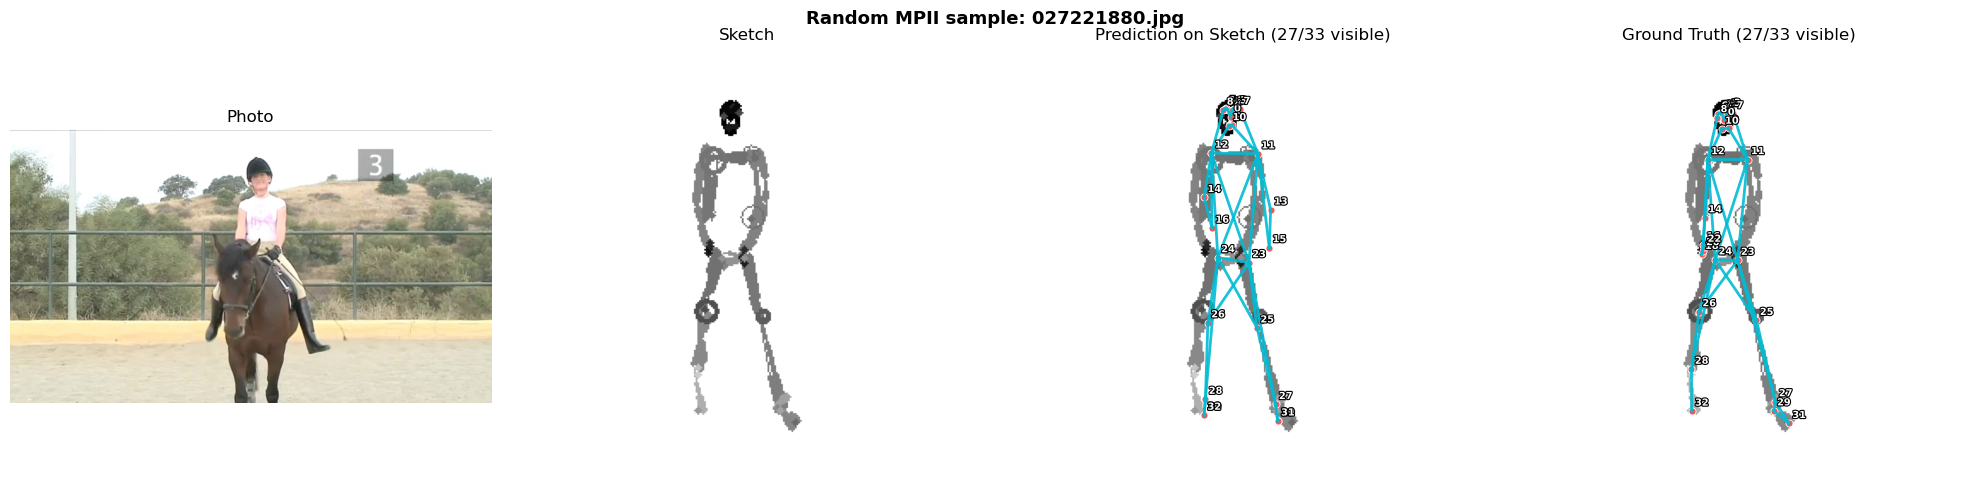

In [ ]:
# Random demo from MPII: photo, sketch, prediction on sketch, and ground truth

def _draw_pose_overlay(ax, image_rgb, coords, vis_mask, title):
    """Draw skeleton overlay on an RGB image using normalized coords in [0, 1]."""
    h, w = image_rgb.shape[:2]
    ax.imshow(image_rgb)

    for (a, b) in EDGES_RAW:
        if vis_mask[a] and vis_mask[b]:
            x1, y1 = coords[a, 0] * w, coords[a, 1] * h
            x2, y2 = coords[b, 0] * w, coords[b, 1] * h
            ax.plot([x1, x2], [y1, y2], color="#00bcd4", linewidth=2.0, alpha=0.9)

    for j in range(len(coords)):
        x, y = coords[j, 0] * w, coords[j, 1] * h
        if vis_mask[j]:
            ax.scatter(x, y, s=26, c="#ff5252", edgecolors="white", linewidths=0.6)
            ax.text(
                x + 2,
                y - 2,
                str(j),
                color="white",
                fontsize=7,
                fontweight="bold",
                ha="left",
                va="bottom",
                path_effects=[pe.withStroke(linewidth=1.6, foreground="black")],
            )

    ax.set_title(title)
    ax.axis("off")


def demo_random_mpii_sample(model, vis_threshold=0.4):
    # 1) Pick a random image from MPII
    image_dir = Path(f"{PATH}/mpii_human_pose_v1/images")
    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.jpeg")) + list(image_dir.glob("*.png"))
    if not image_paths:
        raise FileNotFoundError(f"No images found in: {image_dir}")

    img_path = random.choice(image_paths)

    # 2) Detect pose with MediaPipe
    base_options = python.BaseOptions(model_asset_path=f"{PATH}/pose_landmarker_full.task")
    detector = vision.PoseLandmarker.create_from_options(
        vision.PoseLandmarkerOptions(
            base_options=base_options,
            output_segmentation_masks=False,
        )
    )

    mp_img = mp.Image.create_from_file(str(img_path))
    detection_result = detector.detect(mp_img)

    if not detection_result.pose_landmarks:
        print(f"No pose detected for {img_path.name}. Try running again.")
        return

    # 3) Build normalized skeleton + GT targets
    skeleton = construct_skeleton_from_mediapipe_result(
        detection_result,
        edges,
        normalize_to_bbox=True,
        bbox_padding=0.2,
    )
    gt_coords = skeleton.joints.astype(np.float32)  # (33, 3)
    gt_vis = np.array([m["visibility"] for m in skeleton.joint_meta], dtype=np.float32)
    gt_mask = gt_vis >= vis_threshold

    # 4) Render sketch from the same skeleton style pipeline
    sketch_skel = stylize_as_sketch(skeleton)
    sketch_rgba = sketch_skel.render(size=IMG_SIZE)
    sketch_rgb = composite_sketch_on_white(sketch_rgba)  # (IMG_SIZE,IMG_SIZE,3)

    # 5) Run model prediction on sketch
    sketch_64 = cv2.resize(sketch_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    x = torch.tensor(sketch_64).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred_coords_t, pred_vis_t = model(x)

    pred_coords = pred_coords_t.squeeze(0).cpu().numpy()   # (33,3)
    pred_vis = pred_vis_t.squeeze(0).cpu().numpy()         # (33,)
    pred_mask = pred_vis >= vis_threshold
    if not pred_mask.any():
        pred_mask[np.argmax(pred_vis)] = True

    # 6) Display panels
    photo_rgb = mp_img.numpy_view()[:, :, :3]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Random MPII sample: {img_path.name}", fontsize=13, fontweight="bold")

    axes[0].imshow(photo_rgb)
    axes[0].set_title("Photo")
    axes[0].axis("off")

    axes[1].imshow(sketch_rgb)
    axes[1].set_title("Sketch")
    axes[1].axis("off")

    _draw_pose_overlay(
        axes[2],
        sketch_rgb,
        pred_coords,
        pred_mask,
        title=f"Prediction on Sketch ({pred_mask.sum()}/{NUM_JOINTS} visible)",
    )

    _draw_pose_overlay(
        axes[3],
        sketch_rgb,
        gt_coords,
        gt_mask,
        title=f"Ground Truth ({gt_mask.sum()}/{NUM_JOINTS} visible)",
    )

    plt.tight_layout()
    plt.show()


# Run demo (uses loaded_model from the load cell)
demo_random_mpii_sample(loaded_model, vis_threshold=0.4)


### Run on your own sketch / photo

In [ ]:
# file = "IMG_1722.jpeg"
# sketch_gray = create_sketch_from_image(file)   # function from original notebook
#
# # OR load a PNG sketch directly:
# # sketch_gray = cv2.imread(f"{PATH}/my_sketch.png")
#
# visualise_prediction(model, sketch_gray)
print("Uncomment to run on a custom image.")


## Evaluation – PCK@k

In [43]:
train_loader, val_loader = build_loaders(
        f"{PATH}/GAT_cache", max_chunks=10,
        batch_size=8, seed=42)

def evaluate_pck(model, loader, thresholds=(0.05, 0.10, 0.15),
                 vis_threshold=0.4):
    """
    Percentage of Correct Keypoints (PCK) at multiple normalised-distance thresholds.
    Distance is normalised by the torso diagonal (hip-to-shoulder) per sample.
    """
    model.eval()
    hits   = {t: 0 for t in thresholds}
    totals = {t: 0 for t in thresholds}

    with torch.no_grad():
        for x, coords_gt, vis_gt in tqdm.tqdm(loader, desc="Eval"):
            x, coords_gt, vis_gt = x.to(DEVICE), coords_gt.to(DEVICE), vis_gt.to(DEVICE)
            coords_pred, vis_pred = model(x)

            # Normalise by torso size per sample
            # torso diag: distance between l_shldr(11) and r_hip(24)
            torso_diag = torch.norm(coords_gt[:,11,:] - coords_gt[:,24,:],
                                    dim=-1, keepdim=True).unsqueeze(-1) + 1e-6  # (B,1,1)

            dist = torch.norm(coords_pred - coords_gt, dim=-1) / torso_diag.squeeze(-1)  # (B,J)
            vis_mask = (vis_gt >= vis_threshold)  # (B,J)

            for t in thresholds:
                correct = (dist < t) & vis_mask
                hits[t]   += correct.sum().item()
                totals[t] += vis_mask.sum().item()

    print("\nPCK Evaluation:")
    for t in thresholds:
        pck = 100.0 * hits[t] / max(totals[t], 1)
        print(f"  PCK@{t:.2f}: {pck:.2f}%  ({hits[t]}/{totals[t]} visible joints)")

evaluate_pck(loaded_model, val_loader)

Train: 3784 | Val: 946 | Chunks: 10


Eval: 100%|██████████| 119/119 [00:17<00:00,  6.69it/s]


PCK Evaluation:
  PCK@0.05: 14.82%  (3954/26675 visible joints)
  PCK@0.10: 43.06%  (11485/26675 visible joints)
  PCK@0.15: 63.69%  (16988/26675 visible joints)
